In [1]:
# Put this in a cell BEFORE importing paddleocr / creating PaddleOCR
import os
os.environ["FLAGS_use_mkldnn"] = "0"     # disable oneDNN (MKLDNN)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # sometimes helps on Windows envs
os.environ["FLAGS_use_new_executor"] = "0"

In [2]:
import numpy as np
import json
from PIL import Image, ImageDraw, ImageFont
import re
import unicodedata
from pathlib import Path
from typing import List, Dict, Any, Tuple
import cv2

In [3]:
INPUT_PNG_DIR = Path("./data/jap_imgs_tech/otsu")          # <-- change if needed
OUT_DIR  = Path("./outputs/jap_outputs_test")

OUT_DIR.mkdir(parents=True, exist_ok=True)

png_files = sorted(INPUT_PNG_DIR.glob("*.png"))
print("Found PNGs:", len(png_files))
if png_files:
    print("Example:", png_files[0])

Found PNGs: 6
Example: data\jap_imgs_tech\otsu\pg_1.png


In [4]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(
    lang='japan',
    ocr_version="PP-OCRv5",
    text_detection_model_name="PP-OCRv5_server_det",
    text_recognition_model_name="PP-OCRv5_server_rec",
    use_doc_orientation_classify=True,
    use_doc_unwarping=True,
    use_textline_orientation=True,
    device = "gpu")

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
C:\Users\abcdj\AppData\Local\Temp\ipykernel_16884\3746255328.py:3: UserWarning: `lang` and `ocr_version` will be ignored when model names or model directories are not `None`.
  ocr = PaddleOCR(
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\abcdj\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\abcdj\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\abcdj\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)

In [5]:
# function to get only important values
def create_res_dict(res_out) -> dict:
    assert len(res_out['dt_polys']) == len(res_out['rec_texts']) == len(res_out['rec_scores']), "Length mismatch in polys, texts, scores"

    return_dict = {
        'input': res_out['input_path'],
        'output_img': res_out['doc_preprocessor_res']['output_img'],
        'lang': 'japan',
        'polys': res_out['dt_polys'],
        'texts': res_out['rec_texts'],
        'scores': res_out['rec_scores']
    }

    return return_dict

import cv2
import numpy as np

def undo_right_angle_rotation(img, polys, angle_deg):
    """
    angle_deg = angle used during preprocessing
    This undoes it for image + OCR polys
    Supports: 90, -90, 180, 270, -270
    """
    h, w = img.shape[:2]
    a = angle_deg % 360

    if a == 270:
        # preprocessing rotated +90, so undo with -90
        out_img = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)

        new_polys = []
        for poly in polys:
            new_poly = []
            for x, y in poly:
                nx = y
                ny = w - 1 - x
                new_poly.append([int(nx), int(ny)])
            new_polys.append(new_poly)

    elif a == 90:
        # preprocessing rotated -90, so undo with +90
        out_img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

        new_polys = []
        for poly in polys:
            new_poly = []
            for x, y in poly:
                nx = h - 1 - y
                ny = x
                new_poly.append([int(nx), int(ny)])
            new_polys.append(new_poly)

    elif a == 180:
        out_img = cv2.rotate(img, cv2.ROTATE_180)

        new_polys = []
        for poly in polys:
            new_poly = []
            for x, y in poly:
                nx = w - 1 - x
                ny = h - 1 - y
                new_poly.append([int(nx), int(ny)])
            new_polys.append(new_poly)

    elif a == 0:
        out_img = img.copy()
        new_polys = polys

    else:
        raise ValueError("Use this only for 90/180/270 rotations.")

    return out_img, new_polys

def reprocessed_main_dict(res_out):
    assert len(res_out['dt_polys']) == len(res_out['rec_texts']) == len(res_out['rec_scores']), "Length mismatch in polys, texts, scores"

    angle= res_out['doc_preprocessor_res']['angle']
    img = res_out['doc_preprocessor_res']['output_img']
    old_polys = res_out['dt_polys']

    fixed_img, fixed_polys = undo_right_angle_rotation(img, old_polys, angle)

    return_dict = {
        'input': res_out['input_path'],
        'output_img': fixed_img,
        'lang': 'en',
        'polys': fixed_polys,
        'texts': res_out['rec_texts'],
        'scores': res_out['rec_scores']
    }
    
    return return_dict

# helper function to display the OCR results on the image
def visualize_ocr_results(res_dict: dict) -> Image.Image:
    vis = np.array(res_dict['output_img'], dtype=np.uint8)
    vis = np.ascontiguousarray(vis)

    polys = res_dict['polys']
    for it in polys:
        pts = np.array(it, dtype=np.int32)
        cv2.polylines(vis, [pts], True, (0, 255, 0), 2)

    img_pil = Image.fromarray(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(img_pil)
    font = ImageFont.truetype("NotoSansCJKjp-VF.ttf", 20)

    for i, poly in enumerate(res_dict['polys']):
        pts = np.array(poly, dtype=np.int32)
        text = res_dict['texts'][i]
        x = int(np.min(pts[:, 0]))
        y = max(int(np.min(pts[:, 1])) - 24, 0)

        draw.rectangle([x, y, x + 8 * max(len(text), 1), y + 24], fill=(0, 255, 0))
        draw.text((x + 2, y), f"{i}: {text}", font=font, fill=(0, 0, 0))

    # img_rgb = cv2.cvtColor(img_pil, cv2.COLOR_BGR2RGB)
    return img_pil

In [20]:
# Merging pipeline v4: full coverage + stable iterative text propagation
import re
import cv2
import unicodedata
import numpy as np

# ----------------------------
# Geometry helpers
# ----------------------------
def _p4_poly_to_bbox(poly):
    pts = np.array(poly, dtype=np.int32)
    return [int(np.min(pts[:, 0])), int(np.min(pts[:, 1])), int(np.max(pts[:, 0])), int(np.max(pts[:, 1]))]

def _p4_bbox_to_poly(b):
    x1, y1, x2, y2 = b
    return np.array([[x1, y1], [x2, y1], [x2, y2], [x1, y2]], dtype=np.int32)

def _p4_dims(b):
    x1, y1, x2, y2 = b
    return max(1, x2 - x1), max(1, y2 - y1)

def _p4_center(b):
    x1, y1, x2, y2 = b
    return ((x1 + x2) / 2.0, (y1 + y2) / 2.0)

def _p4_area(b):
    w, h = _p4_dims(b)
    return w * h

def _p4_intersection(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    return max(0, ix2 - ix1) * max(0, iy2 - iy1)

def _p4_containment(inner, outer):
    return _p4_intersection(inner, outer) / max(1, _p4_area(inner))

def _p4_x_overlap_ratio(a, b):
    ax1, _, ax2, _ = a
    bx1, _, bx2, _ = b
    inter = max(0, min(ax2, bx2) - max(ax1, bx1))
    denom = min(max(1, ax2 - ax1), max(1, bx2 - bx1))
    return inter / max(1, denom)

def _p4_y_overlap_ratio(a, b):
    _, ay1, _, ay2 = a
    _, by1, _, by2 = b
    inter = max(0, min(ay2, by2) - max(ay1, by1))
    denom = min(max(1, ay2 - ay1), max(1, by2 - by1))
    return inter / max(1, denom)

def _p4_x_gap(a, b):
    ax1, _, ax2, _ = a
    bx1, _, bx2, _ = b
    if ax2 < bx1:
        return bx1 - ax2
    if bx2 < ax1:
        return ax1 - bx2
    return 0

def _p4_y_gap(a, b):
    _, ay1, _, ay2 = a
    _, by1, _, by2 = b
    if ay2 < by1:
        return by1 - ay2
    if by2 < ay1:
        return ay1 - by2
    return 0

def _p4_expand(b, px=14):
    x1, y1, x2, y2 = b
    return [x1 - px, y1 - px, x2 + px, y2 + px]

def _p4_touching_or_near(a, b, pad=2):
    ea = _p4_expand(a, pad)
    eb = _p4_expand(b, pad)
    return _p4_intersection(ea, eb) > 0


# ----------------------------
# Text helpers
# ----------------------------
def _p4_norm_text(t):
    t = unicodedata.normalize("NFKC", str(t or ""))
    t = re.sub(r"[\u200b\u200c\u200d\ufeff]", "", t)
    t = re.sub(r"\s+", "", t)
    return t

def _p4_is_noise(t):
    t = str(t or "").strip()
    if not t:
        return True
    if len(t) == 1 and t in {"|", "-", "_", "~", "`", "."}:
        return True
    return False

def _p4_strip_alpha_numeric(t):
    t = _p4_norm_text(t)
    t = re.sub(r'[A-Za-z0-9]+', '', t)
    return t.strip()

def _p4_is_vertical(b, ratio=1.15):
    w, h = _p4_dims(b)
    return h > ratio * w


def _p4_iou(a, b):
    inter = _p4_intersection(a, b)
    union = _p4_area(a) + _p4_area(b) - inter
    return inter / max(1, union)

def _p4_is_duplicate_item(a, b, iou_thr=0.75):
    ta = _p4_norm_text(a.get("text", ""))
    tb = _p4_norm_text(b.get("text", ""))
    if not ta or not tb:
        return False

    # same text + strongly overlapping boxes
    if ta == tb and _p4_iou(a["bbox_xyxy"], b["bbox_xyxy"]) >= iou_thr:
        return True

    # contained duplicate case
    if ta == tb:
        if _p4_containment(a["bbox_xyxy"], b["bbox_xyxy"]) >= 0.85:
            return True
        if _p4_containment(b["bbox_xyxy"], a["bbox_xyxy"]) >= 0.85:
            return True

    return False

def _p4_remove_duplicates(items):
    kept = []
    for item in sorted(items, key=lambda x: (x.get("conf") is None, -(x.get("conf") or 0))):
        is_dup = False
        for prev in kept:
            if _p4_is_duplicate_item(item, prev):
                is_dup = True
                break
        if not is_dup:
            kept.append(item)
    return kept

# ----------------------------
# Build source items
# ----------------------------

def undo_right_angle_rotation(img, polys, angle_deg):
    """
    angle_deg = angle used during preprocessing
    This undoes it for image + OCR polys
    Supports: 90, -90, 180, 270, -270
    """
    h, w = img.shape[:2]
    a = angle_deg % 360

    if a == 270:
        # preprocessing rotated +90, so undo with -90
        out_img = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)

        new_polys = []
        for poly in polys:
            new_poly = []
            for x, y in poly:
                nx = y
                ny = w - 1 - x
                new_poly.append([int(nx), int(ny)])
            new_polys.append(new_poly)

    elif a == 90:
        # preprocessing rotated -90, so undo with +90
        out_img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

        new_polys = []
        for poly in polys:
            new_poly = []
            for x, y in poly:
                nx = h - 1 - y
                ny = x
                new_poly.append([int(nx), int(ny)])
            new_polys.append(new_poly)

    elif a == 180:
        out_img = cv2.rotate(img, cv2.ROTATE_180)

        new_polys = []
        for poly in polys:
            new_poly = []
            for x, y in poly:
                nx = w - 1 - x
                ny = h - 1 - y
                new_poly.append([int(nx), int(ny)])
            new_polys.append(new_poly)

    elif a == 0:
        out_img = img.copy()
        new_polys = polys

    else:
        raise ValueError("Use this only for 90/180/270 rotations.")

    return out_img, new_polys

def _p4_make_res_dict_from_ocr_result(res_out):
    assert len(res_out['dt_polys']) == len(res_out['rec_texts']) == len(res_out['rec_scores']), "Length mismatch in polys, texts, scores"

    angle= res_out['doc_preprocessor_res']['angle']
    img = res_out['doc_preprocessor_res']['output_img']
    old_polys = res_out['dt_polys']

    fixed_img, fixed_polys = undo_right_angle_rotation(img, old_polys, angle)

    return_dict = {
        'input': res_out['input_path'],
        'output_img': fixed_img,
        'lang': 'en',
        'polys': fixed_polys,
        'texts': res_out['rec_texts'],
        'scores': res_out['rec_scores']
    }
    
    return return_dict

def _p4_too_small(bbox, min_w=8, min_h=8):
    w, h = _p4_dims(bbox)
    return w < min_w or h < min_h

def _p4_build_items(res_dict):
    items = []
    for i, (poly, text, score) in enumerate(zip(res_dict["polys"], res_dict["texts"], res_dict["scores"])):
        bbox = _p4_poly_to_bbox(poly)
        if _p4_too_small(bbox):
            continue
        raw = str(text or "").strip()

        # remove only English letters and digits, keep Japanese and special chars
        clean = _p4_strip_alpha_numeric(raw)

        # drop empty / junk after cleaning
        if not clean or _p4_is_noise(clean):
            continue

        orientation = "vertical" if _p4_is_vertical(bbox) else "horizontal"
        items.append({
            "id": i,
            "poly": np.array(poly, dtype=np.int32),
            "bbox_xyxy": bbox,
            "text": clean,
            "raw_text": raw,
            "cleaned_text": clean,
            "conf": float(score) if score is not None else None,
            "orientation": orientation,
            "source_box_indices": [i],
            "source_confidences": [float(score)] if score is not None else [],
        })

    items = _p4_remove_duplicates(items)
    return items

# ----------------------------
# Region split (bubble/panel proxy)
# ----------------------------
def _p4_connected_regions(items, expand_px=16):
    if not items:
        return []
    n = len(items)
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for i in range(n):
        bi = _p4_expand(items[i]["bbox_xyxy"], expand_px)
        for j in range(i + 1, n):
            bj = _p4_expand(items[j]["bbox_xyxy"], expand_px)
            if _p4_intersection(bi, bj) > 0:
                union(i, j)

    groups = {}
    for i in range(n):
        groups.setdefault(find(i), []).append(items[i])
    return list(groups.values())

# ----------------------------
# Main merge rules
# ----------------------------
def _p4_should_merge(a, b):
    ba, bb = a["bbox_xyxy"], b["bbox_xyxy"]
    wa, ha = _p4_dims(ba)
    wb, hb = _p4_dims(bb)

    if _p4_containment(ba, bb) >= 0.72 or _p4_containment(bb, ba) >= 0.72:
        return True

    xov = _p4_x_overlap_ratio(ba, bb)
    yov = _p4_y_overlap_ratio(ba, bb)
    xgap = _p4_x_gap(ba, bb)
    ygap = _p4_y_gap(ba, bb)

    if a["orientation"] == "vertical" and b["orientation"] == "vertical":
        ref_w = min(wa, wb)
        ref_h = min(ha, hb)

        # 1. true overlap or almost-touching columns
        # near_x = xgap <= max(3, int(0.22 * ref_w))

        # # 2. they should align meaningfully in y
        # enough_y_overlap = yov >= 0.28

        # # 3. prevent stacking far apart vertically
        # near_y = ygap <= max(6, int(0.18 * ref_h))

        near_x = xgap <= max(6, int(0.35 * ref_w))
        enough_y = yov >= 0.25
        near_y = ygap <= max(8, int(0.20 * ref_h))
        return near_x and enough_y and near_y

    if a["orientation"] == "horizontal" and b["orientation"] == "horizontal":
        cax, cay = _p4_center(ba)
        cbx, cby = _p4_center(bb)

        avg_w = (wa + wb) / 2.0
        avg_h = (ha + hb) / 2.0

        gap_x = bb[0] - ba[2]
        gap_y = bb[1] - ba[3]

        # row-wise merge
        row_near_y = abs(cay - cby) <= max(10, int(0.95 * avg_h))
        row_enough_x_overlap = gap_x >= -50
        row_near_x = gap_x <= min(70, int(2.0 * avg_h))

        # stacked merge
        stack_near_y = (-15 <= gap_y <= max(25, int(1.0 * avg_h)))
        stack_enough_x_overlap = abs(cax - cbx) <= max(20, int(0.9 * avg_w))
        stack_near_x = True

        near_y = row_near_y or stack_near_y
        enough_x_overlap = row_enough_x_overlap or stack_enough_x_overlap
        near_x = row_near_x or stack_near_x

        return near_y and enough_x_overlap and near_x

    return False

def _p4_merge_group(members):
    unique_members = []
    seen_ids = set()

    for m in members:
        mid = m.get("id", None)
        if mid is not None:
            if mid in seen_ids:
                continue
            seen_ids.add(mid)
        unique_members.append(m)

    members = unique_members

    orientation = members[0]["orientation"]
    if orientation == "vertical":
        ordered = sorted(
            members,
            key=lambda m: (-_p4_center(m["bbox_xyxy"])[0], _p4_center(m["bbox_xyxy"])[1])
        )
    else:
        ordered = sorted(
            members,
            key=lambda m: (_p4_center(m["bbox_xyxy"])[0], _p4_center(m["bbox_xyxy"])[1])
        )
        

    xs1 = [m["bbox_xyxy"][0] for m in ordered]
    ys1 = [m["bbox_xyxy"][1] for m in ordered]
    xs2 = [m["bbox_xyxy"][2] for m in ordered]
    ys2 = [m["bbox_xyxy"][3] for m in ordered]
    merged_bbox = [min(xs1), min(ys1), max(xs2), max(ys2)]

    text_main = "".join([m.get("text", "") for m in ordered if m.get("text", "")])
    raw_main = "".join([m.get("raw_text", "") for m in ordered if m.get("raw_text", "")])

    src_pairs = []
    for m in ordered:
        idxs = m.get("source_box_indices", [])
        confs = m.get("source_confidences", [])
        for k, idx in enumerate(idxs):
            conf = confs[k] if k < len(confs) else None
            src_pairs.append((idx, conf))

    seen_src = set()
    dedup_pairs = []
    for idx, conf in src_pairs:
        if idx in seen_src:
            continue
        seen_src.add(idx)
        dedup_pairs.append((idx, conf))

    src_idx = [idx for idx, _ in dedup_pairs]
    src_conf = [conf for _, conf in dedup_pairs]
    confs = [c for c in src_conf if c is not None]
    avg_conf = sum(confs) / len(confs) if confs else None

    # Critical for iterative merging: keep `text` populated in merged items.
    merged_text = text_main if text_main else (raw_main if raw_main else "?")

    return {
        "bbox_xyxy": merged_bbox,
        "poly": _p4_bbox_to_poly(merged_bbox),
        "orientation": orientation,
        "text": merged_text,
        "text_main": merged_text,
        "text_furigana": "",
        "text_augmented": merged_text,
        "raw_text": raw_main,
        "cleaned_text": merged_text,
        "conf": avg_conf,
        "members": ordered,
        "merged_from": len(src_idx) if src_idx else len(ordered),
        "source_box_indices": src_idx,
        "source_confidences": src_conf,
    }

def _p4_iterative_merge(items, max_iters=12):
    current = items[:]
    for _ in range(max_iters):
        used = [False] * len(current)
        new_items = []
        changed = False

        for i in range(len(current)):
            if used[i]:
                continue
            group = [current[i]]
            used[i] = True
            expanded = True
            while expanded:
                expanded = False
                for j in range(len(current)):
                    if used[j]:
                        continue
                    if any(_p4_should_merge(g, current[j]) for g in group):
                        group.append(current[j])
                        used[j] = True
                        expanded = True
                        changed = True
            new_items.append(_p4_merge_group(group))

        current = new_items
        if not changed:
            break
    return current

# ----------------------------
# Furigana vs inline-insert logic
# ----------------------------
def _p4_find_parent(main_blocks, child):
    cb = child["bbox_xyxy"]
    candidates = []

    for i, p in enumerate(main_blocks):
        # if p["orientation"] != "vertical":
        #     continue

        pb = p["bbox_xyxy"]

        # must be near and overlap enough
        if _p4_y_overlap_ratio(cb, pb) < 0.45:
            continue

        if _p4_x_gap(cb, pb) > max(6, int(0.35 * _p4_dims(pb)[0])):
            continue

        ccx, ccy = _p4_center(cb)
        pcx, pcy = _p4_center(pb)
        dist = abs(ccx - pcx) + 0.25 * abs(ccy - pcy)
        candidates.append((dist, i))

    if not candidates:
        return None, None

    candidates.sort()
    _, best_i = candidates[0]
    return best_i, 1.0

def _p4_find_member_for_furigana(parent, child):
    members = parent.get("members", [])
    if not members:
        return None

    best_idx = None
    best_score = -1e9
    cb = child["bbox_xyxy"]

    for i, m in enumerate(members):
        mb = m["bbox_xyxy"]
        yov = _p4_y_overlap_ratio(cb, mb)
        xgap = _p4_x_gap(cb, mb)
        if yov < 0.35:
            continue
        score = 5.0 * yov - 0.5 * xgap
        if score > best_score:
            best_score = score
            best_idx = i

    return best_idx

def _p4_furigana_candidate(child, parent):
    cb, pb = child["bbox_xyxy"], parent["bbox_xyxy"]
    cw, ch = _p4_dims(cb)
    pw, ph = _p4_dims(pb)

    # small relative size
    if cw > 0.55 * pw:
        return False
    if ch > 0.45 * ph:
        return False
    if _p4_area(cb) > 0.22 * _p4_area(pb):
        return False

    # must overlap vertically with parent column
    if _p4_y_overlap_ratio(cb, pb) < 0.45:
        return False

    # must be close on x, beside the parent
    xgap = _p4_x_gap(cb, pb)
    if xgap > max(6, int(0.35 * pw)):
        return False

    # should not be too far above/below
    _, ccy = _p4_center(cb)
    _, pcy = _p4_center(pb)
    if abs(ccy - pcy) > 0.60 * ph:
        return False

    return True

def _p4_is_symbol_or_punct_only(t):
    """
    True if text is only punctuation / symbols / marks / separators.
    This catches things like:
    ".", "...", "!!", "?", "・", "…", "—", "ー", "【】", "α", "β", "Σ", etc.
    """
    t = _p4_norm_text(t)
    if not t:
        return True

    for ch in t:
        cat = unicodedata.category(ch)
        # P* = punctuation, S* = symbol, M* = mark, Z* = separator
        if not (cat[0] in {"P", "S", "M", "Z"}):
            return False
    return True


def _p4_should_drop_text(raw_text, clean_text, bbox,
                         min_w=8, min_h=8, min_area=70):
    t = _p4_norm_text(clean_text)
    if not t:
        return True

    if _p4_is_symbol_or_punct_only(t):
        return True

    if len(t) == 1:
        ch = t[0]
        w, h = _p4_dims(bbox)
        area = w * h

        if _p4_is_japanese_char(ch):
            # keep only if big enough
            return not (w >= min_w and h >= min_h and area >= min_area)

        # non-Japanese single chars always removed
        return True

    return False

def _p4_is_japanese_char(ch):
    code = ord(ch)
    return (
        0x3040 <= code <= 0x309F or   # Hiragana
        0x30A0 <= code <= 0x30FF or   # Katakana
        0x4E00 <= code <= 0x9FFF or   # Kanji
        0x3400 <= code <= 0x4DBF or   # CJK Ext A
        ch in {"々", "〆", "〇", "ヶ", "ゝ", "ゞ", "ヽ", "ヾ"}
    )

def _p4_filter_final_blocks(blocks, min_w=8, min_h=8, min_area=70):
    kept = []

    for b in blocks:
        bbox = b["bbox_xyxy"]
        w, h = _p4_dims(bbox)
        area = w * h
        t = b.get("text_augmented", "") or b.get("text", "")

        if w < min_w or h < min_h or area < min_area:
            continue

        if _p4_should_drop_text(
            t,
            t,
            bbox,
            min_w=min_w,
            min_h=min_h,
            min_area=min_area
        ):
            continue

        kept.append(b)

    return kept

    return kept

def _p4_insertion_char_index(parent, child):
    members = parent.get("members", [])
    if not members:
        return len(parent.get("text_main", ""))

    if parent["orientation"] == "vertical":
        ordered = sorted(
            members,
            key=lambda m: (-_p4_center(m["bbox_xyxy"])[0], _p4_center(m["bbox_xyxy"])[1])
        )
        child_key = (-_p4_center(child["bbox_xyxy"])[0], _p4_center(child["bbox_xyxy"])[1])
        key_fn = lambda m: (-_p4_center(m["bbox_xyxy"])[0], _p4_center(m["bbox_xyxy"])[1])
    else:
        ordered = sorted(members, key=lambda m: (_p4_center(m["bbox_xyxy"])[0], _p4_center(m["bbox_xyxy"])[1]))
        child_key = (_p4_center(child["bbox_xyxy"])[0], _p4_center(child["bbox_xyxy"])[1])
        key_fn = lambda m: (_p4_center(m["bbox_xyxy"])[0], _p4_center(m["bbox_xyxy"])[1])

    idx_member = 0
    for k, m in enumerate(ordered):
        if key_fn(m) <= child_key:
            idx_member = k + 1
        else:
            break

    char_idx = 0
    for m in ordered[:idx_member]:
        char_idx += len(str(m.get("text", "")))
    return max(0, min(char_idx, len(parent.get("text_main", ""))))



def _p4_attach_aux(main_blocks, aux_items):
    leftover = []
    for c in aux_items:
        pi, score = _p4_find_parent(main_blocks, c)
        if pi is None or score < 0.45:
            leftover.append(c)
            continue

        parent = main_blocks[pi]
        if _p4_furigana_candidate(c, parent):
            parent.setdefault("furigana_items", []).append(c)
        else:
            ins = _p4_insertion_char_index(parent, c)
            parent.setdefault("inline_insertions", []).append((ins, c))

    for b in main_blocks:
        members = b.get("members", [])
        member_furi = {i: [] for i in range(len(members))}

        for it in b.get("furigana_items", []):
            mi = _p4_find_member_for_furigana(b, it)
            if mi is not None:
                member_furi[mi].append(it)

        parts = []
        for i, m in enumerate(members):
            main_t = m.get("text", "")
            furi_items = sorted(
                member_furi[i],
                key=lambda it: (_p4_center(it["bbox_xyxy"])[1], _p4_center(it["bbox_xyxy"])[0])
            )
            furi_t = "".join(it.get("text", "") for it in furi_items if it.get("text", ""))
            if furi_t:
                parts.append(f"{main_t}[{furi_t}]")
            else:
                parts.append(main_t)

        b["text_main"] = "".join(m.get("text", "") for m in members)
        b["text_furigana"] = "".join(
            "".join(it.get("text", "") for it in member_furi[i])
            for i in range(len(members))
        )
        b["text_augmented"] = "".join(parts) if parts else b.get("text_main", "")
    return main_blocks, leftover

# ----------------------------
# Reading order + pipeline
# ----------------------------

def _p4_drop_combined_blocks_prefer_atomic(blocks):
    keep = []

    for i, b in enumerate(blocks):
        b_text = _p4_norm_text(b.get("text_augmented", ""))
        b_src = set(b.get("source_box_indices", []))

        drop_b = False
        for j, c in enumerate(blocks):
            if i == j:
                continue

            c_text = _p4_norm_text(c.get("text_augmented", ""))
            c_src = set(c.get("source_box_indices", []))

            if not b_text or not c_text:
                continue

            # if c is a smaller standalone block contained in b text/source coverage,
            # prefer keeping c and dropping the larger contaminated combined block b
            if c_text in b_text and c_text != b_text:
                if c_src and b_src and c_src.issubset(b_src):
                    drop_b = True
                    break

        if not drop_b:
            keep.append(b)

    return keep

def _p4_sort_reading_order(blocks):
    def key(b):
        x1, y1, _, _ = b["bbox_xyxy"]
        if b["orientation"] == "vertical":
            # vertical: top->bottom inside column, columns right->left
            return (0, -x1, y1)
        # horizontal: left->right then top->bottom
        return (1, y1, x1)
    return sorted(blocks, key=key)

def _p4_make_passthrough(item):
    t = item.get("text", "?") or "?"
    return {
        "bbox_xyxy": item["bbox_xyxy"],
        "poly": item["poly"],
        "orientation": item["orientation"],
        "text": t,
        "text_main": t,
        "text_furigana": "",
        "text_augmented": t,
        "raw_text": item.get("raw_text", t),
        "cleaned_text": item.get("cleaned_text", t),
        "conf": item.get("conf", None),
        "members": [item],
        "merged_from": 1,
        "source_box_indices": item.get("source_box_indices", []),
        "source_confidences": item.get("source_confidences", []),
    }

def build_translation_ready_japanese_ocr_v4(res_dict):
    items = _p4_build_items(res_dict)
    regions = _p4_connected_regions(items, expand_px=6)

    all_blocks = []
    for ridx, region_items in enumerate(regions):
        vertical_items = [it for it in region_items if it["orientation"] == "vertical"]
        horizontal_items = [it for it in region_items if it["orientation"] == "horizontal"]

        merged_vertical = _p4_iterative_merge(vertical_items) if vertical_items else []
        merged_horizontal = _p4_iterative_merge(horizontal_items) if horizontal_items else []

        # Aux candidates: not currently represented in merged members.
        used_ids = set()
        for m in merged_vertical + merged_horizontal:
            for sm in m.get("members", []):
                if sm.get("id") is not None:
                    used_ids.add(sm["id"])
        aux_candidates = [it for it in region_items if it.get("id") not in used_ids]

        merged_vertical, leftover_aux = _p4_attach_aux(merged_vertical, aux_candidates)

        passthrough = [_p4_make_passthrough(it) for it in leftover_aux]
        region_blocks = merged_vertical + merged_horizontal + passthrough

        for b in region_blocks:
            b["region_id"] = ridx
            if not b.get("text_main", ""):
                b["text_main"] = b.get("text", "?") or "?"
                b["text_augmented"] = b["text_main"]

        all_blocks.extend(region_blocks)

    # Global coverage enforcement: every source index must appear at least once.
    source_indices_all = set()
    for it in items:
        source_indices_all.update(it.get("source_box_indices", []))

    source_indices_used = set()
    for b in all_blocks:
        source_indices_used.update(b.get("source_box_indices", []))

    missing = sorted(list(source_indices_all - source_indices_used))
    if missing:
        by_id = {it["id"]: it for it in items if "id" in it}
        for mid in missing:
            if mid in by_id:
                all_blocks.append(_p4_make_passthrough(by_id[mid]))

    all_blocks = _p4_drop_combined_blocks_prefer_atomic(all_blocks)
    all_blocks = _p4_filter_final_blocks(all_blocks)
    ordered = _p4_sort_reading_order(all_blocks)
    for i, b in enumerate(ordered):
        b["reading_order_index"] = i

    out_res_dict = {
        "input": res_dict["input"],
        "output_img": res_dict["output_img"],
        "lang": res_dict.get("lang", "japan"),
        "polys": [np.array(b["poly"], dtype=np.int32) for b in ordered],
        "texts": [b["text_augmented"] for b in ordered],
        "scores": [b.get("conf", None) for b in ordered],
    }
    return out_res_dict, ordered

def export_translation_blocks_v4(blocks):
    out = []
    for b in blocks:
        out.append({
            "text_main": b.get("text_main", ""),
            "text_furigana": b.get("text_furigana", ""),
            "text_augmented": b.get("text_augmented", ""),
            "orientation": b.get("orientation", "vertical"),
            "reading_order_index": b.get("reading_order_index", -1),
            "bbox_xyxy": b.get("bbox_xyxy", [0, 0, 0, 0]),
            "source_box_indices": b.get("source_box_indices", []),
            "source_confidences": b.get("source_confidences", []),
            "raw_text": b.get("raw_text", ""),
            "cleaned_text": b.get("cleaned_text", ""),
        })
    return out

# Example run + coverage diagnostics
# res_dict_v4 = _p4_make_res_dict_from_ocr_result(res_ocr)
# translation_res_dict_v4, translation_blocks_v4 = build_translation_ready_japanese_ocr_v4(res_dict_v4)

# all_src = set(range(len(res_dict_v4["texts"])))
# used_src = set()
# for b in translation_blocks_v4:
#     used_src.update(b.get("source_box_indices", []))
# missing_src = sorted(list(all_src - used_src))

# print("Original OCR boxes:", len(res_dict_v4["polys"]))
# print("Translation-ready blocks:", len(translation_blocks_v4))
# print("Covered source indices:", len(used_src), "/", len(all_src))
# print("Missing source indices:", missing_src[:20], "..." if len(missing_src) > 20 else "")
# for i, b in enumerate(translation_blocks_v4[:25]):
#     print(f"{i}: main={b['text_main']} | furi={b['text_furigana']} | aug={b['text_augmented']} | src={b.get('source_box_indices', [])}")

# display(visualize_ocr_results(translation_res_dict_v4))

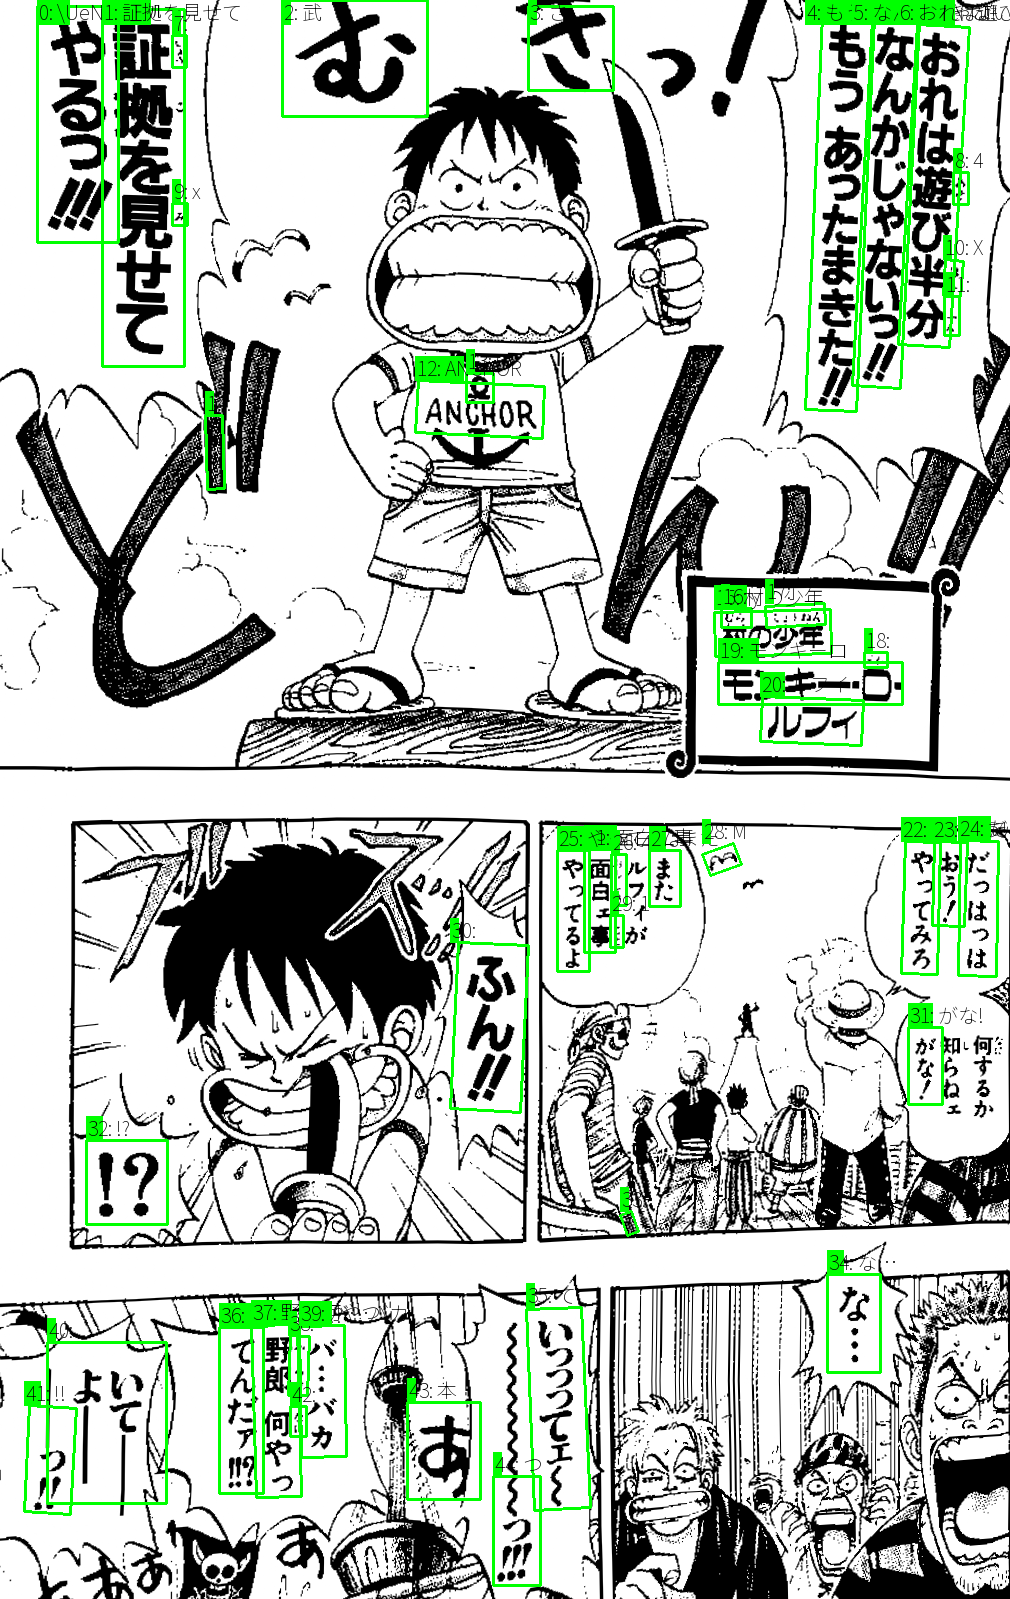

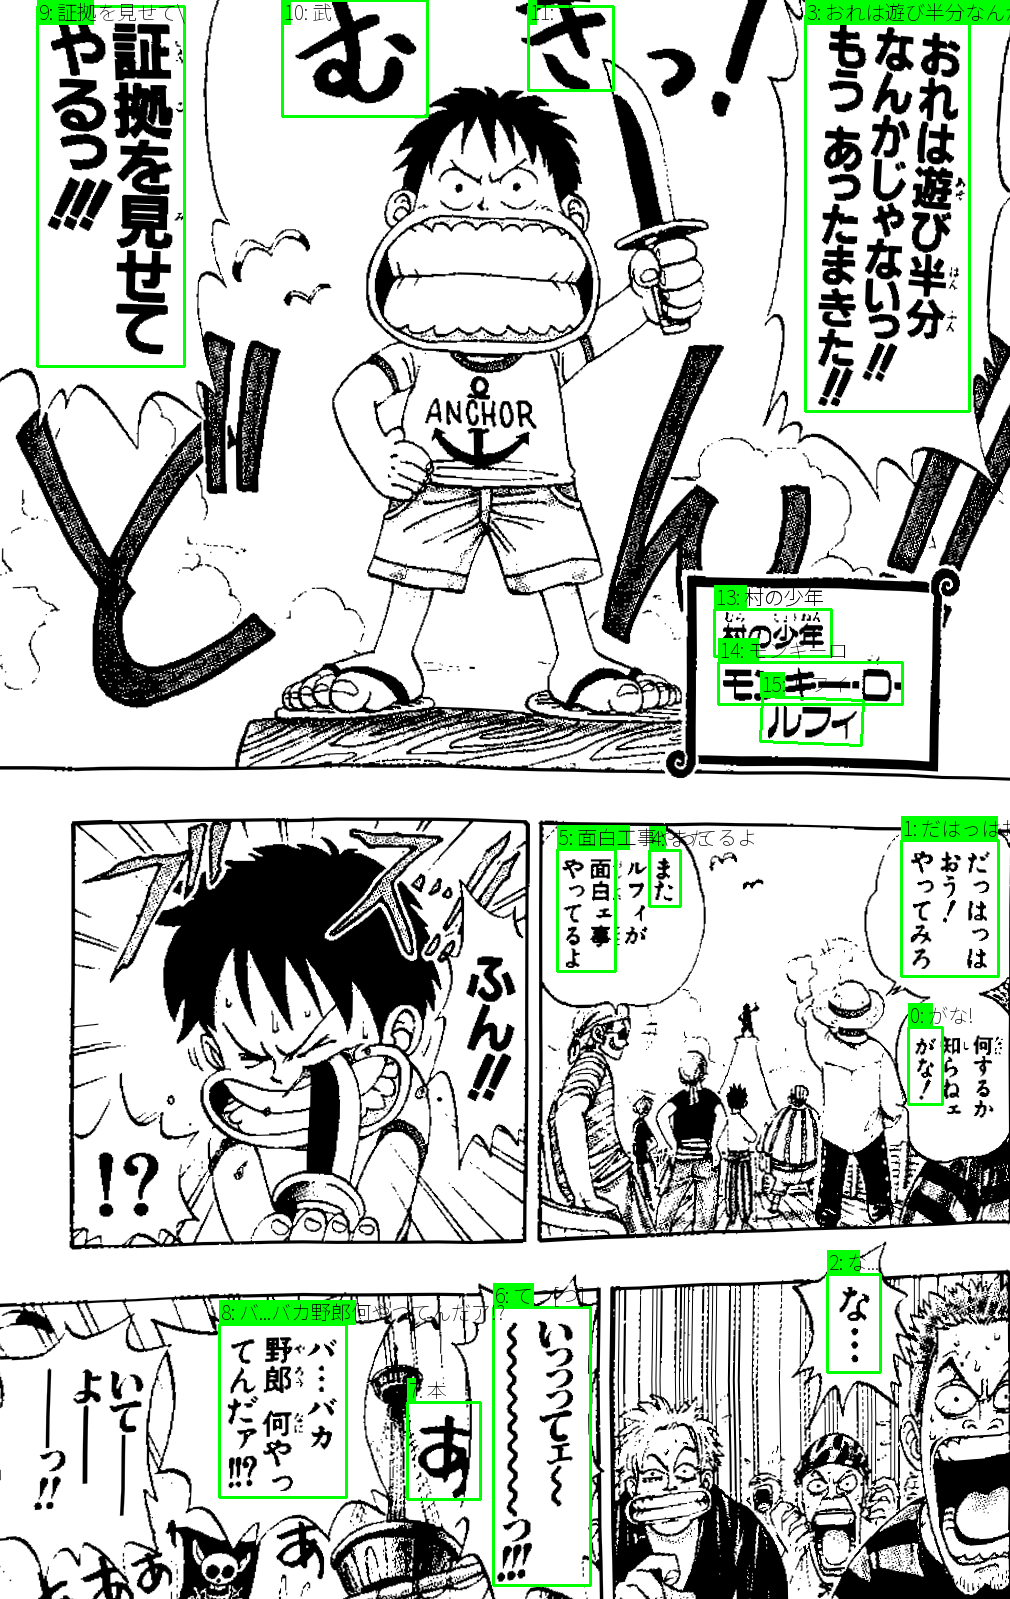

In [21]:
temp = png_files[1]
res_ocr = ocr.predict(str(temp))[0]
basic_dict = reprocessed_main_dict(res_ocr)
res_dict_v4 = _p4_make_res_dict_from_ocr_result(res_ocr)
translation_res_dict_v4, translation_blocks_v4 = build_translation_ready_japanese_ocr_v4(res_dict_v4)
translation_res_dict_v4, translation_blocks_v4 = build_translation_ready_japanese_ocr_v4(translation_res_dict_v4)
display(visualize_ocr_results(basic_dict))
display(visualize_ocr_results(translation_res_dict_v4))

In [ ]:
ocr_dicts = []
for png_path in png_files:
    print("Processing:", png_path.name)
    res_ocr = ocr.predict(str(png_path))[0]
    # translation_res_dict_v4 = reprocessed_main_dict(res_ocr)
    res_dict_v4 = _p4_make_res_dict_from_ocr_result(res_ocr)
    translation_res_dict_v4, translation_blocks_v4 = build_translation_ready_japanese_ocr_v4(res_dict_v4)
    display(visualize_ocr_results(translation_res_dict_v4))
    ocr_dicts.append(translation_res_dict_v4)

In [19]:
def numpy_converter(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.bool_):
        return bool(obj)
    raise TypeError(f"Object of type {type(obj).__name__} is not JSON serializable")

In [27]:
def save_results(res_dicts, out_path):
    json_dir = f"{out_path}/json"
    vis_dir = f"{out_path}/vis"
    base_dir = f"{out_path}/base"
    os.makedirs(json_dir, exist_ok=True)
    os.makedirs(vis_dir, exist_ok=True)
    os.makedirs(base_dir, exist_ok=True)

    for res_dict in res_dicts:
        base_name = os.path.basename(res_dict["input"]).replace(".png", "")
        print("Saving results for:", base_name)
        json_path = os.path.join(json_dir, f"{base_name}.json")
        vis_path = os.path.join(vis_dir, f"{base_name}.png")
        base_path = os.path.join(base_dir, f"{base_name}.png")

        vis_img = visualize_ocr_results(res_dict)
        vis_img.save(vis_path)

        base_img = Image.fromarray(cv2.cvtColor(res_dict['output_img'], cv2.COLOR_BGR2RGB))
        base_img.save(base_path)

        del res_dict['output_img']

        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(res_dict, f, default=numpy_converter, ensure_ascii=False, indent=2)
        
        print(f"Saved info for: {base_name}")

In [28]:
save_results(ocr_dicts, "./output_test")

Saving results for: pg_1
Saved info for: pg_1
Saving results for: pg_2
Saved info for: pg_2
Saving results for: pg_3
Saved info for: pg_3
Saving results for: pg_4
Saved info for: pg_4
Saving results for: pg_5
Saved info for: pg_5
Saving results for: pg_6
Saved info for: pg_6


In [ ]:
# Merging pipeline v4: full coverage + stable iterative text propagation
import re
import unicodedata
import numpy as np

# ----------------------------
# Geometry helpers
# ----------------------------
def _p4_poly_to_bbox(poly):
    pts = np.array(poly, dtype=np.int32)
    return [int(np.min(pts[:, 0])), int(np.min(pts[:, 1])), int(np.max(pts[:, 0])), int(np.max(pts[:, 1]))]

def _p4_bbox_to_poly(b):
    x1, y1, x2, y2 = b
    return np.array([[x1, y1], [x2, y1], [x2, y2], [x1, y2]], dtype=np.int32)

def _p4_dims(b):
    x1, y1, x2, y2 = b
    return max(1, x2 - x1), max(1, y2 - y1)

def _p4_center(b):
    x1, y1, x2, y2 = b
    return ((x1 + x2) / 2.0, (y1 + y2) / 2.0)

def _p4_area(b):
    w, h = _p4_dims(b)
    return w * h

def _p4_intersection(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    return max(0, ix2 - ix1) * max(0, iy2 - iy1)

def _p4_containment(inner, outer):
    return _p4_intersection(inner, outer) / max(1, _p4_area(inner))

def _p4_x_overlap_ratio(a, b):
    ax1, _, ax2, _ = a
    bx1, _, bx2, _ = b
    inter = max(0, min(ax2, bx2) - max(ax1, bx1))
    denom = min(max(1, ax2 - ax1), max(1, bx2 - bx1))
    return inter / max(1, denom)

def _p4_y_overlap_ratio(a, b):
    _, ay1, _, ay2 = a
    _, by1, _, by2 = b
    inter = max(0, min(ay2, by2) - max(ay1, by1))
    denom = min(max(1, ay2 - ay1), max(1, by2 - by1))
    return inter / max(1, denom)

def _p4_x_gap(a, b):
    ax1, _, ax2, _ = a
    bx1, _, bx2, _ = b
    if ax2 < bx1:
        return bx1 - ax2
    if bx2 < ax1:
        return ax1 - bx2
    return 0

def _p4_y_gap(a, b):
    _, ay1, _, ay2 = a
    _, by1, _, by2 = b
    if ay2 < by1:
        return by1 - ay2
    if by2 < ay1:
        return ay1 - by2
    return 0

def _p4_expand(b, px=14):
    x1, y1, x2, y2 = b
    return [x1 - px, y1 - px, x2 + px, y2 + px]


# ----------------------------
# Text helpers
# ----------------------------
def _p4_norm_text(t):
    t = unicodedata.normalize("NFKC", str(t or ""))
    t = re.sub(r"[\u200b\u200c\u200d\ufeff]", "", t)
    t = re.sub(r"\s+", "", t)
    return t

def _p4_is_noise(t):
    t = str(t or "").strip()
    if not t:
        return True
    if len(t) == 1 and t in {"|", "-", "_", "~", "`", "."}:
        return True
    return False

def _p4_strip_alpha_numeric(t):
    t = _p4_norm_text(t)
    t = re.sub(r'[A-Za-z0-9]+', '', t)
    return t.strip()

def _p4_is_vertical(b, ratio=1.15):
    w, h = _p4_dims(b)
    return h > ratio * w


def _p4_iou(a, b):
    inter = _p4_intersection(a, b)
    union = _p4_area(a) + _p4_area(b) - inter
    return inter / max(1, union)

def _p4_is_duplicate_item(a, b, iou_thr=0.75):
    ta = _p4_norm_text(a.get("text", ""))
    tb = _p4_norm_text(b.get("text", ""))
    if not ta or not tb:
        return False

    # same text + strongly overlapping boxes
    if ta == tb and _p4_iou(a["bbox_xyxy"], b["bbox_xyxy"]) >= iou_thr:
        return True

    # contained duplicate case
    if ta == tb:
        if _p4_containment(a["bbox_xyxy"], b["bbox_xyxy"]) >= 0.85:
            return True
        if _p4_containment(b["bbox_xyxy"], a["bbox_xyxy"]) >= 0.85:
            return True

    return False

def _p4_remove_duplicates(items):
    kept = []
    for item in sorted(items, key=lambda x: (x.get("conf") is None, -(x.get("conf") or 0))):
        is_dup = False
        for prev in kept:
            if _p4_is_duplicate_item(item, prev):
                is_dup = True
                break
        if not is_dup:
            kept.append(item)
    return kept

# ----------------------------
# Build source items
# ----------------------------

def undo_right_angle_rotation(img, polys, angle_deg):
    """
    angle_deg = angle used during preprocessing
    This undoes it for image + OCR polys
    Supports: 90, -90, 180, 270, -270
    """
    h, w = img.shape[:2]
    a = angle_deg % 360

    if a == 270:
        # preprocessing rotated +90, so undo with -90
        out_img = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)

        new_polys = []
        for poly in polys:
            new_poly = []
            for x, y in poly:
                nx = y
                ny = w - 1 - x
                new_poly.append([int(nx), int(ny)])
            new_polys.append(new_poly)

    elif a == 90:
        # preprocessing rotated -90, so undo with +90
        out_img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

        new_polys = []
        for poly in polys:
            new_poly = []
            for x, y in poly:
                nx = h - 1 - y
                ny = x
                new_poly.append([int(nx), int(ny)])
            new_polys.append(new_poly)

    elif a == 180:
        out_img = cv2.rotate(img, cv2.ROTATE_180)

        new_polys = []
        for poly in polys:
            new_poly = []
            for x, y in poly:
                nx = w - 1 - x
                ny = h - 1 - y
                new_poly.append([int(nx), int(ny)])
            new_polys.append(new_poly)

    elif a == 0:
        out_img = img.copy()
        new_polys = polys

    else:
        raise ValueError("Use this only for 90/180/270 rotations.")

    return out_img, new_polys

def _p4_make_res_dict_from_ocr_result(res_out):
    assert len(res_out['dt_polys']) == len(res_out['rec_texts']) == len(res_out['rec_scores']), "Length mismatch in polys, texts, scores"

    angle= res_out['doc_preprocessor_res']['angle']
    img = res_out['doc_preprocessor_res']['output_img']
    old_polys = res_out['dt_polys']

    fixed_img, fixed_polys = undo_right_angle_rotation(img, old_polys, angle)

    return_dict = {
        'input': res_out['input_path'],
        'output_img': fixed_img,
        'lang': 'en',
        'polys': fixed_polys,
        'texts': res_out['rec_texts'],
        'scores': res_out['rec_scores']
    }
    
    return return_dict

def _p4_build_items(res_dict):
    items = []
    for i, (poly, text, score) in enumerate(zip(res_dict["polys"], res_dict["texts"], res_dict["scores"])):
        bbox = _p4_poly_to_bbox(poly)
        raw = str(text or "").strip()

        # remove only English letters and digits, keep Japanese and special chars
        clean = _p4_strip_alpha_numeric(raw)

        # drop empty / junk after cleaning
        if not clean or _p4_is_noise(clean):
            continue

        orientation = "vertical" if _p4_is_vertical(bbox) else "horizontal"
        items.append({
            "id": i,
            "poly": np.array(poly, dtype=np.int32),
            "bbox_xyxy": bbox,
            "text": clean,
            "raw_text": raw,
            "cleaned_text": clean,
            "conf": float(score) if score is not None else None,
            "orientation": orientation,
            "source_box_indices": [i],
            "source_confidences": [float(score)] if score is not None else [],
        })

    items = _p4_remove_duplicates(items)
    return items

# ----------------------------
# Region split (bubble/panel proxy)
# ----------------------------
def _p4_connected_regions(items, expand_px=16):
    if not items:
        return []
    n = len(items)
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for i in range(n):
        bi = _p4_expand(items[i]["bbox_xyxy"], expand_px)
        for j in range(i + 1, n):
            bj = _p4_expand(items[j]["bbox_xyxy"], expand_px)
            if _p4_intersection(bi, bj) > 0:
                union(i, j)

    groups = {}
    for i in range(n):
        groups.setdefault(find(i), []).append(items[i])
    return list(groups.values())

# ----------------------------
# Main merge rules
# ----------------------------
def _p4_should_merge(a, b):
    ba, bb = a["bbox_xyxy"], b["bbox_xyxy"]
    wa, ha = _p4_dims(ba)
    wb, hb = _p4_dims(bb)
    cxa, cya = _p4_center(ba)
    cxb, cyb = _p4_center(bb)

    if _p4_containment(ba, bb) >= 0.72 or _p4_containment(bb, ba) >= 0.72:
        return True

    xov = _p4_x_overlap_ratio(ba, bb)
    yov = _p4_y_overlap_ratio(ba, bb)
    xgap = _p4_x_gap(ba, bb)
    ygap = _p4_y_gap(ba, bb)

    if a["orientation"] == "vertical" and b["orientation"] == "vertical":
        ref_w = min(wa, wb)
        ref_h = min(ha, hb)
        return (
            xgap <= 1.8 * ref_w and
            yov >= 0.45 and
            ygap <= 2.5 * ref_h
        )

    if a["orientation"] == "horizontal" and b["orientation"] == "horizontal":
        dy = abs(cya - cyb)
        ref_w = min(wa, wb)
        ref_h = min(ha, hb)
        return dy <= 1.0 * ref_h and xgap <= 2.4 * ref_w and yov >= 0.18

    return False

def _p4_merge_group(members):
    unique_members = []
    seen_ids = set()

    for m in members:
        mid = m.get("id", None)
        if mid is not None:
            if mid in seen_ids:
                continue
            seen_ids.add(mid)
        unique_members.append(m)

    members = unique_members

    orientation = members[0]["orientation"]
    if orientation == "vertical":
        ordered = sorted(
            members,
            key=lambda m: (-_p4_center(m["bbox_xyxy"])[0], _p4_center(m["bbox_xyxy"])[1])
        )
    else:
        ordered = sorted(
            members,
            key=lambda m: (_p4_center(m["bbox_xyxy"])[0], _p4_center(m["bbox_xyxy"])[1])
        )
        

    xs1 = [m["bbox_xyxy"][0] for m in ordered]
    ys1 = [m["bbox_xyxy"][1] for m in ordered]
    xs2 = [m["bbox_xyxy"][2] for m in ordered]
    ys2 = [m["bbox_xyxy"][3] for m in ordered]
    merged_bbox = [min(xs1), min(ys1), max(xs2), max(ys2)]

    text_main = "".join([m.get("text", "") for m in ordered if m.get("text", "")])
    raw_main = "".join([m.get("raw_text", "") for m in ordered if m.get("raw_text", "")])

    src_pairs = []
    for m in ordered:
        idxs = m.get("source_box_indices", [])
        confs = m.get("source_confidences", [])
        for k, idx in enumerate(idxs):
            conf = confs[k] if k < len(confs) else None
            src_pairs.append((idx, conf))

    seen_src = set()
    dedup_pairs = []
    for idx, conf in src_pairs:
        if idx in seen_src:
            continue
        seen_src.add(idx)
        dedup_pairs.append((idx, conf))

    src_idx = [idx for idx, _ in dedup_pairs]
    src_conf = [conf for _, conf in dedup_pairs]
    confs = [c for c in src_conf if c is not None]
    avg_conf = sum(confs) / len(confs) if confs else None

    # Critical for iterative merging: keep `text` populated in merged items.
    merged_text = text_main if text_main else (raw_main if raw_main else "?")

    return {
        "bbox_xyxy": merged_bbox,
        "poly": _p4_bbox_to_poly(merged_bbox),
        "orientation": orientation,
        "text": merged_text,
        "text_main": merged_text,
        "text_furigana": "",
        "text_augmented": merged_text,
        "raw_text": raw_main,
        "cleaned_text": merged_text,
        "conf": avg_conf,
        "members": ordered,
        "merged_from": len(src_idx) if src_idx else len(ordered),
        "source_box_indices": src_idx,
        "source_confidences": src_conf,
    }

def _p4_iterative_merge(items, max_iters=12):
    current = items[:]
    for _ in range(max_iters):
        used = [False] * len(current)
        new_items = []
        changed = False

        for i in range(len(current)):
            if used[i]:
                continue
            group = [current[i]]
            used[i] = True
            expanded = True
            while expanded:
                expanded = False
                for j in range(len(current)):
                    if used[j]:
                        continue
                    if any(_p4_should_merge(g, current[j]) for g in group):
                        group.append(current[j])
                        used[j] = True
                        expanded = True
                        changed = True
            new_items.append(_p4_merge_group(group))

        current = new_items
        if not changed:
            break
    return current

# ----------------------------
# Furigana vs inline-insert logic
# ----------------------------
def _p4_find_parent(main_blocks, child):
    cb = child["bbox_xyxy"]
    best_i = None
    best = -1e9
    for i, p in enumerate(main_blocks):
        if p["orientation"] != "vertical":
            continue
        pb = p["bbox_xyxy"]
        yov = _p4_y_overlap_ratio(cb, pb)
        xov = _p4_x_overlap_ratio(cb, pb)
        ccx, ccy = _p4_center(cb)
        pcx, pcy = _p4_center(pb)
        dist = abs(ccx - pcx) + 0.15 * abs(ccy - pcy)
        score = 7.0 * yov + 1.8 * xov - 0.01 * dist
        if score > best:
            best = score
            best_i = i
    return best_i, best

def _p4_furigana_candidate(child, parent):
    # Requested rule: furigana usually <= 4 chars.
    if len(child.get("text", "")) > 4:
        return False

    cb, pb = child["bbox_xyxy"], parent["bbox_xyxy"]
    cw, ch = _p4_dims(cb)
    pw, ph = _p4_dims(pb)
    if _p4_area(cb) > 0.30 * _p4_area(pb):
        return False
    if cw > 0.82 * pw or ch > 0.92 * ph:
        return False
    if _p4_y_overlap_ratio(cb, pb) < 0.18:
        return False

    ccx, _ = _p4_center(cb)
    pcx, _ = _p4_center(pb)
    lateral = abs(ccx - pcx)
    if lateral < 0.08 * pw or lateral > 1.95 * pw:
        return False
    return True

def _p4_insertion_char_index(parent, child):
    members = parent.get("members", [])
    if not members:
        return len(parent.get("text_main", ""))

    if parent["orientation"] == "vertical":
        ordered = sorted(
            members,
            key=lambda m: (-_p4_center(m["bbox_xyxy"])[0], _p4_center(m["bbox_xyxy"])[1])
        )
        child_key = (-_p4_center(child["bbox_xyxy"])[0], _p4_center(child["bbox_xyxy"])[1])
        key_fn = lambda m: (-_p4_center(m["bbox_xyxy"])[0], _p4_center(m["bbox_xyxy"])[1])
    else:
        ordered = sorted(members, key=lambda m: (_p4_center(m["bbox_xyxy"])[0], _p4_center(m["bbox_xyxy"])[1]))
        child_key = (_p4_center(child["bbox_xyxy"])[0], _p4_center(child["bbox_xyxy"])[1])
        key_fn = lambda m: (_p4_center(m["bbox_xyxy"])[0], _p4_center(m["bbox_xyxy"])[1])

    idx_member = 0
    for k, m in enumerate(ordered):
        if key_fn(m) <= child_key:
            idx_member = k + 1
        else:
            break

    char_idx = 0
    for m in ordered[:idx_member]:
        char_idx += len(str(m.get("text", "")))
    return max(0, min(char_idx, len(parent.get("text_main", ""))))

def _p4_attach_aux(main_blocks, aux_items):
    leftover = []
    for c in aux_items:
        pi, score = _p4_find_parent(main_blocks, c)
        if pi is None or score < 0.45:
            leftover.append(c)
            continue

        parent = main_blocks[pi]
        if _p4_furigana_candidate(c, parent):
            parent.setdefault("furigana_items", []).append(c)
        else:
            ins = _p4_insertion_char_index(parent, c)
            parent.setdefault("inline_insertions", []).append((ins, c))

    for b in main_blocks:
        text_main = b.get("text_main", "")
        insertions = sorted(b.get("inline_insertions", []), key=lambda t: t[0], reverse=True)
        for ins, c in insertions:
            text_main = text_main[:ins] + c.get("text", "") + text_main[ins:]
            b["source_box_indices"].extend(c.get("source_box_indices", []))
            b["source_confidences"].extend(c.get("source_confidences", []))
        b["text_main"] = text_main if text_main else b.get("text", "?")

        furi_items = sorted(
            b.get("furigana_items", []),
            key=lambda it: (_p4_center(it["bbox_xyxy"])[1], _p4_center(it["bbox_xyxy"])[0])
        )
        furi = "".join([it.get("text", "") for it in furi_items if it.get("text", "")])
        b["text_furigana"] = furi
        b["text_augmented"] = f"{b['text_main']}[{furi}]" if furi else b["text_main"]

        for it in furi_items:
            b["source_box_indices"].extend(it.get("source_box_indices", []))
            b["source_confidences"].extend(it.get("source_confidences", []))

    return main_blocks, leftover

# ----------------------------
# Reading order + pipeline
# ----------------------------
def _p4_sort_reading_order(blocks):
    def key(b):
        x1, y1, _, _ = b["bbox_xyxy"]
        if b["orientation"] == "vertical":
            # vertical: top->bottom inside column, columns right->left
            return (0, -x1, y1)
        # horizontal: left->right then top->bottom
        return (1, y1, x1)
    return sorted(blocks, key=key)

def _p4_make_passthrough(item):
    t = item.get("text", "?") or "?"
    return {
        "bbox_xyxy": item["bbox_xyxy"],
        "poly": item["poly"],
        "orientation": item["orientation"],
        "text": t,
        "text_main": t,
        "text_furigana": "",
        "text_augmented": t,
        "raw_text": item.get("raw_text", t),
        "cleaned_text": item.get("cleaned_text", t),
        "conf": item.get("conf", None),
        "members": [item],
        "merged_from": 1,
        "source_box_indices": item.get("source_box_indices", []),
        "source_confidences": item.get("source_confidences", []),
    }

def build_translation_ready_japanese_ocr_v4(res_dict):
    items = _p4_build_items(res_dict)
    regions = _p4_connected_regions(items, expand_px=16)

    all_blocks = []
    for ridx, region_items in enumerate(regions):
        vertical_items = [it for it in region_items if it["orientation"] == "vertical"]
        horizontal_items = [it for it in region_items if it["orientation"] == "horizontal"]

        merged_vertical = _p4_iterative_merge(vertical_items) if vertical_items else []
        merged_horizontal = _p4_iterative_merge(horizontal_items) if horizontal_items else []

        # Aux candidates: not currently represented in merged members.
        used_ids = set()
        for m in merged_vertical + merged_horizontal:
            for sm in m.get("members", []):
                if sm.get("id") is not None:
                    used_ids.add(sm["id"])
        aux_candidates = [it for it in region_items if it.get("id") not in used_ids]

        merged_vertical, leftover_aux = _p4_attach_aux(merged_vertical, aux_candidates)

        passthrough = [_p4_make_passthrough(it) for it in leftover_aux]
        region_blocks = merged_vertical + merged_horizontal + passthrough

        for b in region_blocks:
            b["region_id"] = ridx
            if not b.get("text_main", ""):
                b["text_main"] = b.get("text", "?") or "?"
                b["text_augmented"] = b["text_main"]

        all_blocks.extend(region_blocks)

    # Global coverage enforcement: every source index must appear at least once.
    source_indices_all = set()
    for it in items:
        source_indices_all.update(it.get("source_box_indices", []))

    source_indices_used = set()
    for b in all_blocks:
        source_indices_used.update(b.get("source_box_indices", []))

    missing = sorted(list(source_indices_all - source_indices_used))
    if missing:
        by_id = {it["id"]: it for it in items if "id" in it}
        for mid in missing:
            if mid in by_id:
                all_blocks.append(_p4_make_passthrough(by_id[mid]))

    ordered = _p4_sort_reading_order(all_blocks)
    for i, b in enumerate(ordered):
        b["reading_order_index"] = i

    out_res_dict = {
        "input": res_dict["input"],
        "output_img": res_dict["output_img"],
        "lang": res_dict.get("lang", "japan"),
        "polys": [np.array(b["poly"], dtype=np.int32) for b in ordered],
        "texts": [b["text_augmented"] for b in ordered],
        "scores": [b.get("conf", None) for b in ordered],
    }
    return out_res_dict, ordered

def export_translation_blocks_v4(blocks):
    out = []
    for b in blocks:
        out.append({
            "text_main": b.get("text_main", ""),
            "text_furigana": b.get("text_furigana", ""),
            "text_augmented": b.get("text_augmented", ""),
            "orientation": b.get("orientation", "vertical"),
            "reading_order_index": b.get("reading_order_index", -1),
            "bbox_xyxy": b.get("bbox_xyxy", [0, 0, 0, 0]),
            "source_box_indices": b.get("source_box_indices", []),
            "source_confidences": b.get("source_confidences", []),
            "raw_text": b.get("raw_text", ""),
            "cleaned_text": b.get("cleaned_text", ""),
        })
    return out

# Example run + coverage diagnostics
# res_dict_v4 = _p4_make_res_dict_from_ocr_result(res_ocr)
# translation_res_dict_v4, translation_blocks_v4 = build_translation_ready_japanese_ocr_v4(res_dict_v4)

# all_src = set(range(len(res_dict_v4["texts"])))
# used_src = set()
# for b in translation_blocks_v4:
#     used_src.update(b.get("source_box_indices", []))
# missing_src = sorted(list(all_src - used_src))

# print("Original OCR boxes:", len(res_dict_v4["polys"]))
# print("Translation-ready blocks:", len(translation_blocks_v4))
# print("Covered source indices:", len(used_src), "/", len(all_src))
# print("Missing source indices:", missing_src[:20], "..." if len(missing_src) > 20 else "")
# for i, b in enumerate(translation_blocks_v4[:25]):
#     print(f"{i}: main={b['text_main']} | furi={b['text_furigana']} | aug={b['text_augmented']} | src={b.get('source_box_indices', [])}")

# display(visualize_ocr_results(translation_res_dict_v4))